In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score

In [2]:
data = pd.read_csv(r'D:/Python/DATA/New/House_Price_Prediction_Dataset.csv')

In [3]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [9]:
data['Garage'] = data['Garage'].map({ 'Yes': 1, 'No': 0 })

In [10]:
X = data[['Area' , 'Bedrooms' , 'YearBuilt' , 'Garage']]
Y = data['Price']

In [11]:
X_train,X_test,Y_train,Y_test = train_test_split(X , Y , test_size=0.2 , random_state=42)

In [12]:
model = LinearRegression()
model.fit(X_train , Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
predictions = model.predict(X_test)

In [14]:
mae = mean_absolute_error(Y_test , predictions)
r2 = r2_score(Y_test , predictions)

In [50]:
new_House = pd.DataFrame({
    'Area':[1000] ,
    'Bedrooms':[1] ,
    'YearBuilt':[2000] ,
    'Garage':[1]
})

In [51]:
predicted_price = model.predict(new_House)

In [52]:
print('Predicred Price :' , int(predicted_price) ,'$')

Predicred Price : 541637 $


C:\Users\MILADI\AppData\Local\Temp\ipykernel_2216\3518876944.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Predicred Price :' , int(predicted_price) ,'$')


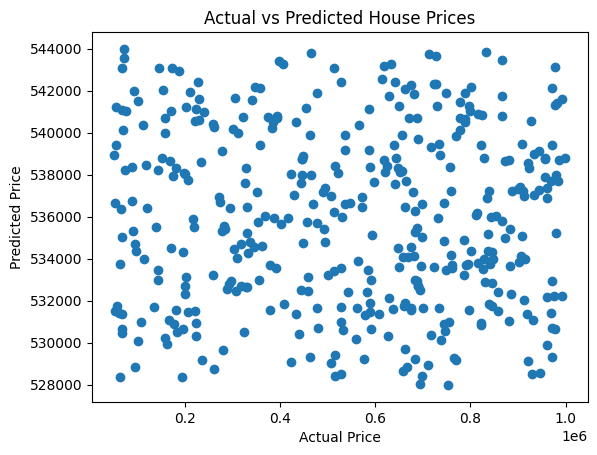

In [53]:
plt.scatter(Y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()